<a href="https://colab.research.google.com/github/dasihayu/artificial-intelegence/blob/main/Jobsheet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Air Quality Dataset (Stasiun Dongsi)
- **Nama:** Dasi Hayu Permana
- **NIM:** 4.33.25.0.06
- **Kelas:** TI-1A

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren rata-rata konsentrasi PM2.5 di Stasiun Dongsi dari tahun 2013 hingga 2017?
- Pertanyaan 2: Pada jam berapa dalam sehari konsentrasi PM2.5 cenderung paling tinggi dan paling rendah?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
air_quality_df = pd.read_csv("https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv")
air_quality_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


### Assessing Data

In [3]:
air_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [4]:
air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,750
PM10,553
SO2,663
NO2,1601
CO,3197


In [5]:
print("Jumlah duplikasi: ", air_quality_df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
air_quality_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,737.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


### Cleaning Data

In [7]:
numeric_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for column in numeric_cols:
    air_quality_df[column] = air_quality_df[column].fillna(air_quality_df[column].median())

air_quality_df["wd"] = air_quality_df["wd"].fillna(air_quality_df["wd"].mode()[0])

air_quality_df["date"] = pd.to_datetime(air_quality_df[["year", "month", "day", "hour"]])

air_quality_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


Setelah proses cleaning, seluruh missing value pada kolom numerik diisi menggunakan nilai median, sedangkan kolom kategorikal `wd` (arah angin) diisi menggunakan nilai modus. Selain itu, kolom `year`, `month`, `day`, dan `hour` digabungkan menjadi satu kolom baru bernama `date` bertipe datetime agar memudahkan analisis time series.

## Exploratory Data Analysis (EDA)

### Explore Konsentrasi PM2.5 Berdasarkan Waktu

In [8]:
print("Rata-rata PM2.5 per tahun:")
display(air_quality_df.groupby(by="year").agg({"PM2.5": ["mean", "min", "max"]}))

print("\nRata-rata PM2.5 per jam:")
display(air_quality_df.groupby(by="hour").agg({"PM2.5": "mean"}))

Rata-rata PM2.5 per tahun:


PM2.5            
            mean  min    max
year                        
2013   86.435185  3.0  520.0
2014   87.176507  3.0  737.0
2015   86.961176  3.0  685.0
2016   79.453324  3.0  695.0
2017  102.596751  3.0  681.0


Rata-rata PM2.5 per jam:


,PM2.5
hour,
0,96.582272
1,96.052977
2,94.486653
3,92.040041
4,88.648871
5,84.757084
6,81.963723
7,79.972074
8,79.609377


## Visualization & Explanatory Analysis

### Pertanyaan 1:

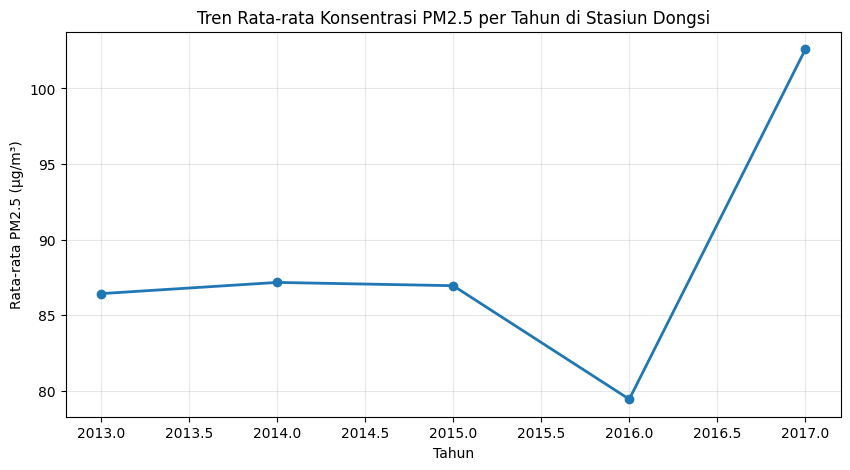

In [9]:
yearly_avg = air_quality_df.groupby(by="year")["PM2.5"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_avg["year"], yearly_avg["PM2.5"], marker="o", linewidth=2, color="#1f77b4")
plt.title("Tren Rata-rata Konsentrasi PM2.5 per Tahun di Stasiun Dongsi")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata PM2.5 (µg/m³)")
plt.grid(True, alpha=0.3)
plt.show()

### Pertanyaan 2:

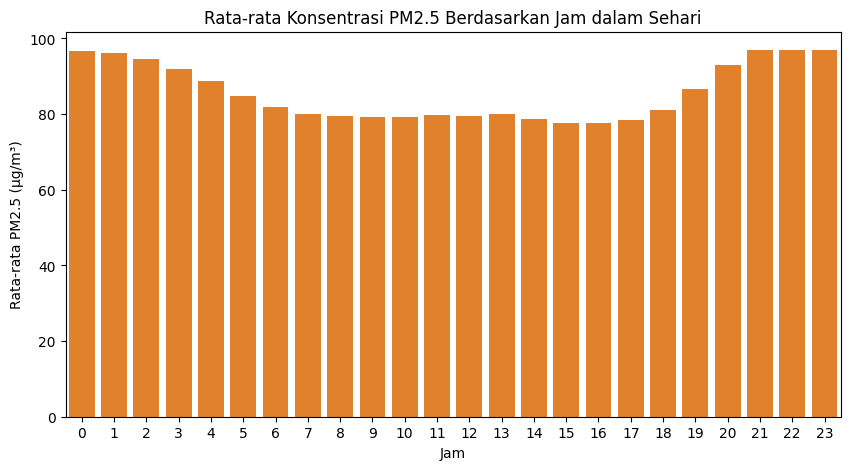

In [10]:
hourly_avg = air_quality_df.groupby(by="hour")["PM2.5"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_avg, x="hour", y="PM2.5", color="#ff7f0e")
plt.title("Rata-rata Konsentrasi PM2.5 Berdasarkan Jam dalam Sehari")
plt.xlabel("Jam")
plt.ylabel("Rata-rata PM2.5 (µg/m³)")
plt.show()

## Conclusion

- Conclusion pertanyaan 1: Rata-rata konsentrasi PM2.5 di Stasiun Dongsi cenderung berfluktuasi dari tahun ke tahun, dengan nilai rata-rata berada di kisaran 79-103 µg/m³. Tahun 2017 menunjukkan rata-rata PM2.5 tertinggi dibandingkan tahun-tahun sebelumnya, mengindikasikan kualitas udara yang cenderung memburuk pada periode tersebut.
- Conclusion pertanyaan 2: Konsentrasi PM2.5 menunjukkan pola harian yang jelas, yaitu cenderung tinggi pada malam hingga dini hari (sekitar pukul 21.00-01.00) dan menurun pada siang hingga sore hari (sekitar pukul 14.00-16.00). Pola ini kemungkinan berkaitan dengan aktivitas manusia dan kondisi atmosfer yang berbeda antara siang dan malam hari.